# Kenya Food Price Intelligence — Modeling
## CRISP-DM Phase 4–5: Modeling & Evaluation

**Capstone Project — Data Science & AI Bootcamp**

---

This notebook continues directly from **`../eda/Kenya_Food_Price_EDA.ipynb`**, which produced the
feature-engineered panel `../eda/wfp_features_engineered.csv` (27,316 market × commodity × month price
records, 2006–2026, with lag / rolling / volatility / rainfall-interaction features).

### Business objective

Give consumers, farmers and traders a **forward-looking** signal instead of lagging, anecdotal price
information. Two concrete modeling tasks:

| # | Task | Type | Target | Use |
|---|------|------|--------|-----|
| **1** | **Price-spike early warning** | Classification | Will this market × commodity be **>15 % above its seasonal norm next month**? | Dashboard alert: *"Kitui maize likely to spike next month"* |
| **2** | **Next-month price forecast** | Regression | `price_per_kg` **one month ahead** | Planning number for procurement / stocking decisions |

Task 2 is a **cross-sectional ML forecaster** — it predicts one month ahead for *every* monitored series
at once, complementing the single-series SARIMA/SARIMAX forecaster in the time-series notebook.

### Modeling data window

We restrict modeling to **2016 onward**. Before 2016 the WFP panel is thin (~300 records/year vs
~5,000/year post-2021) and the expanding-window "seasonal norm" has too little history to be stable,
which produces spurious ±100 % deviations. 2016+ also matches the fuel-price era referenced in the
project's original classification design.

### External enrichment

A reliable public **monthly Kenyan pump-price** series does not exist (EPRA publishes per-cycle press
releases only). Instead we enrich with two **verifiable, citable** cost-push drivers:

* **Brent crude oil**, monthly USD/barrel — FRED series `POILBREUSDM` (the upstream driver of Kenyan
  diesel and therefore transport / food-distribution cost).
* **Implied USD/KES exchange rate** — derived from the dataset itself as the national monthly median of
  `price ÷ usdprice`.

Their product (`brent_kes`) approximates imported-fuel cost pressure in shillings. If a genuine EPRA
fuel CSV is later added to `../../data/raw/`, swap it in at the enrichment step.

## 1. Setup

In [1]:
import warnings, json, pathlib, urllib.request, io
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, f1_score, precision_score, recall_score,
    mean_absolute_error, root_mean_squared_error, r2_score,
)
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb
import joblib

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

NB_DIR   = pathlib.Path.cwd()
ROOT     = (NB_DIR / ".." / "..").resolve()
DATA_DIR = ROOT / "data"
MODEL_DIR = NB_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)
(DATA_DIR / "exports").mkdir(parents=True, exist_ok=True)
print("Project root:", ROOT)

Project root: C:\Users\Admin\Desktop\DSMoringa\capstone\bei-smart


## 2. Load the feature-engineered panel

In [2]:
feat = pd.read_csv(NB_DIR / ".." / "eda" / "wfp_features_engineered.csv", parse_dates=["date"])
feat["month_date"] = feat["date"].values.astype("datetime64[M]")
print(f"Feature-engineered panel: {feat.shape[0]:,} rows x {feat.shape[1]} columns")
print("Date range:", feat["date"].min().date(), "->", feat["date"].max().date())
feat[["date", "market", "commodity_group", "pricetype", "price_per_kg", "usdprice_std",
      "pct_above_seasonal_norm", "volatility_flag"]].head()

Feature-engineered panel: 27,316 rows x 50 columns
Date range: 2006-01-15 -> 2026-08-15


,date,market,commodity_group,pricetype,price_per_kg,usdprice_std,pct_above_seasonal_norm,volatility_flag
0,2024-09-15,Adele Center,Beans,Retail,160.000,1.240,NaN,normal
1,2024-09-15,Adele Center,Maize flour (white),Retail,70.000,0.540,NaN,normal
2,2024-09-15,Adele Center,Rice (aromatic),Retail,120.000,0.930,NaN,normal
3,2024-09-15,Adele Center,Salt,Retail,50.000,0.390,NaN,normal
4,2024-09-15,Adele Center,Sugar,Retail,140.000,1.090,NaN,normal


## 3. External enrichment — Brent crude & implied FX

`fetch_fred` pulls monthly Brent from FRED. If the machine is offline, drop a cached copy at
`../../data/raw/POILBREUSDM.csv` (columns `observation_date,POILBREUSDM`) and it will be used instead.

  POILBREUSDM: 271 months from FRED (live)  (2004-01-01 -> 2026-07-01)


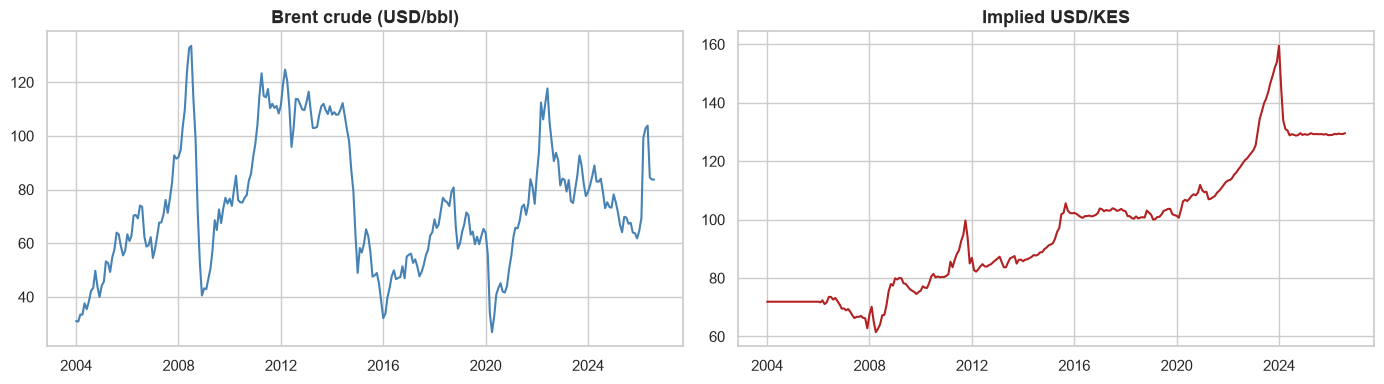

,month_date,brent_usd,usdkes_fx,brent_kes,brent_usd_lag3,brent_usd_lag6,usdkes_fx_lag3,usdkes_fx_lag6,brent_kes_lag3,brent_kes_lag6
269,2026-06-01,84.488,129.310,"10,925.137",99.405,61.811,129.330,128.889,"12,856.010","7,966.739"
270,2026-07-01,83.734,129.294,"10,826.356",102.814,64.594,129.222,128.962,"13,285.831","8,330.168"
271,2026-08-01,83.734,129.590,"10,851.070",103.842,69.409,129.429,128.992,"13,440.235","8,953.242"


In [3]:
def fetch_fred(series_id: str, start="2004-01-01") -> pd.DataFrame:
    cache = DATA_DIR / "raw" / f"{series_id}.csv"
    try:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}&cosd={start}"
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        raw = urllib.request.urlopen(req, timeout=30).read().decode()
        cache.write_text(raw)
        src = "FRED (live)"
    except Exception as e:
        print(f"  live fetch failed ({e}); using cache {cache}")
        raw = cache.read_text()
        src = "local cache"
    s = pd.read_csv(io.StringIO(raw))
    s.columns = ["month_date", series_id]
    s["month_date"] = pd.to_datetime(s["month_date"])
    s[series_id] = pd.to_numeric(s[series_id], errors="coerce")
    print(f"  {series_id}: {len(s)} months from {src}  ({s.month_date.min().date()} -> {s.month_date.max().date()})")
    return s

brent = fetch_fred("POILBREUSDM").rename(columns={"POILBREUSDM": "brent_usd"})

# Implied USD/KES: national monthly median of price / usdprice (guard against junk ratios)
fx = feat.assign(_fx=feat["price"] / feat["usdprice"]).replace([np.inf, -np.inf], np.nan)
fx = (fx[(fx["_fx"] > 50) & (fx["_fx"] < 300)]
      .groupby("month_date")["_fx"].median().rename("usdkes_fx").reset_index())

ext = brent.merge(fx, on="month_date", how="outer").sort_values("month_date")
ext["usdkes_fx"] = ext["usdkes_fx"].interpolate(limit_direction="both")
ext["brent_usd"] = ext["brent_usd"].interpolate(limit_direction="both")
ext["brent_kes"] = ext["brent_usd"] * ext["usdkes_fx"]

# lagged versions — fuel cost passes through to food prices with a delay
for col in ["brent_usd", "usdkes_fx", "brent_kes"]:
    ext[f"{col}_lag3"] = ext[col].shift(3)
    ext[f"{col}_lag6"] = ext[col].shift(6)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(ext["month_date"], ext["brent_usd"], color="steelblue"); ax[0].set_title("Brent crude (USD/bbl)")
ax[1].plot(ext["month_date"], ext["usdkes_fx"], color="firebrick"); ax[1].set_title("Implied USD/KES")
plt.tight_layout(); plt.show()

ext.tail(3)

## 4. Build supervised targets

Both targets are **one calendar month ahead**. To make "next month" mean a true calendar month (series
have gaps), we lay each `(market, commodity, pricetype)` series on a gap-free monthly grid, shift by
`-1`, then merge the target back onto real observations only — no fabricated rows enter training.

* **`y_pricekg_next`** — next month's `price_per_kg` (regression). We also model `y_logprice_next` for a
  variance-stabilised fit (EDA skew ≈ 2.5).
* **`y_spike_next`** — `1` if next month's `pct_above_seasonal_norm` **> 15 %**, else `0`. This is the
  exact rule the EDA uses for the `above_normal` volatility flag, shifted forward one month.

In [4]:
gcols = ["market", "commodity", "pricetype"]
feat = feat.sort_values(gcols + ["month_date"]).reset_index(drop=True)

spans = feat.groupby(gcols, sort=False)["month_date"].agg(["min", "max"]).reset_index()
frames = [pd.DataFrame({"market": r.market, "commodity": r.commodity, "pricetype": r.pricetype,
                        "month_date": pd.date_range(r.min, r.max, freq="MS")})
          for r in spans.itertuples(index=False)]
grid = (pd.concat(frames, ignore_index=True)
        .merge(feat[gcols + ["month_date", "usdprice_std", "price_per_kg", "pct_above_seasonal_norm"]],
               on=gcols + ["month_date"], how="left")
        .sort_values(gcols + ["month_date"]).reset_index(drop=True))
g = grid.groupby(gcols, sort=False)

grid["y_pricekg_next"]     = g["price_per_kg"].shift(-1)
grid["y_usdstd_next"]      = g["usdprice_std"].shift(-1)
grid["next_pct_above_norm"] = g["pct_above_seasonal_norm"].shift(-1)
grid["y_spike_next"]       = np.where(grid["next_pct_above_norm"].notna(),
                                      (grid["next_pct_above_norm"] > 15).astype(float), np.nan)
grid["y_logprice_next"]    = np.log(grid["y_pricekg_next"])

targets = grid[gcols + ["month_date", "y_pricekg_next", "y_usdstd_next", "y_logprice_next",
                        "y_spike_next", "next_pct_above_norm"]]
model_df = feat.merge(ext, on="month_date", how="left").merge(targets, on=gcols + ["month_date"], how="left")
print("Merged modeling frame:", model_df.shape)
print("\nSpike target (all years):")
print(model_df["y_spike_next"].value_counts(dropna=False))

Merged modeling frame: (27316, 64)

Spike target (all years):
y_spike_next
NaN      15996
0.000     7098
1.000     4222
Name: count, dtype: int64


## 5. Assemble the modeling table (2016+, valid history, valid target)

In [5]:
FEAT_NUM = [
    # own-price history
    "price_lag_1", "price_lag_3", "price_lag_12",
    "price_rollmean_3", "price_rollmean_12", "price_rollstd_3", "price_rollstd_6",
    "price_pct_change_mom", "price_pct_change_yoy", "volatility_cv_6m",
    "pct_above_seasonal_norm", "price_zscore",
    # rainfall
    "rainfall_mm", "rainfall_lag_1", "rainfall_lag_3", "rainfall_lag_6", "rainfall_anomaly_pct",
    # macro cost-push
    "brent_usd", "brent_usd_lag3", "brent_kes", "brent_kes_lag3", "usdkes_fx", "usdkes_fx_lag3",
    # calendar / geography
    "month_sin", "month_cos", "year", "latitude", "longitude",
]
FEAT_CAT = ["admin1", "category", "commodity_group", "pricetype", "season", "priceflag"]
ALL_FEATS = FEAT_NUM + FEAT_CAT

MIN_HISTORY = ["price_lag_3", "price_rollmean_3", "price_pct_change_yoy"]  # require ~1yr of history

base = model_df[model_df["year"] >= 2016].copy()

reg_df = base.dropna(subset=["y_pricekg_next"] + MIN_HISTORY).copy()
clf_df = base.dropna(subset=["y_spike_next", "pct_above_seasonal_norm"] + MIN_HISTORY).copy()

print(f"Regression table:     {reg_df.shape[0]:,} rows   ({reg_df.date.min().date()} -> {reg_df.date.max().date()})")
print(f"Classification table: {clf_df.shape[0]:,} rows   ({clf_df.date.min().date()} -> {clf_df.date.max().date()})")
print(f"\nSpike rate: {clf_df['y_spike_next'].mean():.1%}  (imbalanced -> use class weighting)")

# persist the enriched dataset for downstream notebooks / the dashboard
keep = gcols + ["date", "month_date", "admin1", "admin2", "category", "commodity_group",
                "season", "price", "usdprice", "price_per_kg", "usdprice_std"] + \
       [c for c in ALL_FEATS if c not in gcols] + \
       ["y_pricekg_next", "y_logprice_next", "y_spike_next", "next_pct_above_norm"]
enriched_out = model_df[model_df["year"] >= 2016][sorted(set(keep), key=keep.index)]
enriched_path = DATA_DIR / "cleaned" / "bei_smart_modeling.csv"
enriched_out.to_csv(enriched_path, index=False)
print(f"\nSaved enriched modeling dataset -> {enriched_path.relative_to(ROOT)}  {enriched_out.shape}")

Regression table:     4,519 rows   (2016-01-15 -> 2026-07-15)
Classification table: 5,068 rows   (2016-01-15 -> 2026-07-15)

Spike rate: 27.8%  (imbalanced -> use class weighting)



Saved enriched modeling dataset -> data\cleaned\bei_smart_modeling.csv  (23491, 47)


## 6. Temporal train / test split

A random split would leak the future into training (rolling features + macro series are autocorrelated).
We split on **calendar time**: train on everything **before 2024-01-01**, test on **2024-01 onward**
(~19 months of genuinely out-of-sample data, spanning the 2024 harvest glut and the 2025–26 rebound).

Regression  — train 2,864 | test 1,655
Classification — train 3,006 | test 2,062
Spike rate — train 35.1% | test 17.0%


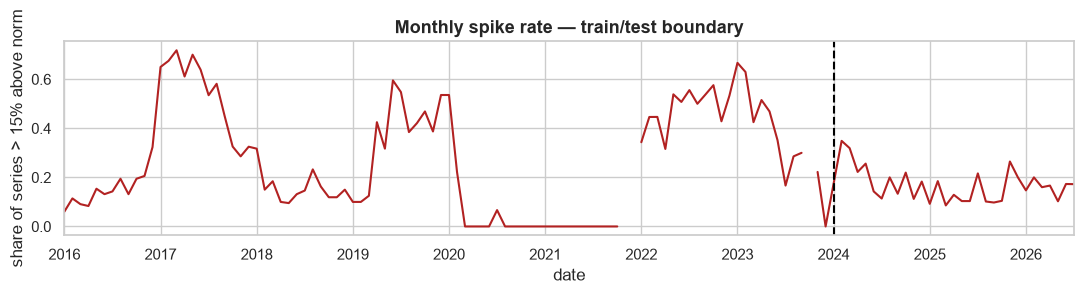

In [6]:
SPLIT_DATE = pd.Timestamp("2024-01-01")

def temporal_split(frame):
    tr = frame[frame["date"] < SPLIT_DATE]
    te = frame[frame["date"] >= SPLIT_DATE]
    return tr, te

reg_tr, reg_te = temporal_split(reg_df)
clf_tr, clf_te = temporal_split(clf_df)

print(f"Regression  — train {len(reg_tr):,} | test {len(reg_te):,}")
print(f"Classification — train {len(clf_tr):,} | test {len(clf_te):,}")
print(f"Spike rate — train {clf_tr['y_spike_next'].mean():.1%} | test {clf_te['y_spike_next'].mean():.1%}")

fig, ax = plt.subplots(figsize=(11, 3))
clf_df.set_index("date").resample("MS")["y_spike_next"].mean().plot(ax=ax, color="firebrick")
ax.axvline(SPLIT_DATE, color="black", ls="--"); ax.set_title("Monthly spike rate — train/test boundary")
ax.set_ylabel("share of series > 15% above norm"); plt.tight_layout(); plt.show()

---
# TASK 1 — Price-spike early-warning classifier

**Metric priority.** The alert is only useful if it *catches* real spikes, but false alarms erode trust.
We lead with **PR-AUC** (average precision) and **recall on the spike class**, report ROC-AUC for
reference, and tune the decision threshold explicitly rather than accepting the default 0.5.

In [7]:
pre_num = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
pre_num_tree = SimpleImputer(strategy="median")
pre_cat = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                    ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=20))])

prep_linear = ColumnTransformer([("num", pre_num, FEAT_NUM), ("cat", pre_cat, FEAT_CAT)])
prep_tree   = ColumnTransformer([("num", pre_num_tree, FEAT_NUM), ("cat", pre_cat, FEAT_CAT)])

Xtr_c, ytr_c = clf_tr[ALL_FEATS], clf_tr["y_spike_next"].astype(int)
Xte_c, yte_c = clf_te[ALL_FEATS], clf_te["y_spike_next"].astype(int)
spw = (ytr_c == 0).sum() / (ytr_c == 1).sum()
print("scale_pos_weight (neg/pos):", round(spw, 2))

scale_pos_weight (neg/pos): 1.85


In [8]:
clf_models = {
    "Dummy (stratified)": Pipeline([("prep", prep_tree),
        ("clf", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE))]),
    "Logistic Regression": Pipeline([("prep", prep_linear),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("prep", prep_tree),
        ("clf", RandomForestClassifier(n_estimators=400, min_samples_leaf=3, n_jobs=-1,
                                       class_weight="balanced_subsample", random_state=RANDOM_STATE))]),
    "XGBoost": Pipeline([("prep", prep_tree),
        ("clf", xgb.XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                                  eval_metric="aucpr", n_jobs=-1, random_state=RANDOM_STATE))]),
    "LightGBM": Pipeline([("prep", prep_tree),
        ("clf", lgb.LGBMClassifier(n_estimators=600, num_leaves=31, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8, class_weight="balanced",
                                   n_jobs=-1, random_state=RANDOM_STATE, verbose=-1))]),
}

rows = []
proba = {}
for name, pipe in clf_models.items():
    pipe.fit(Xtr_c, ytr_c)
    p = pipe.predict_proba(Xte_c)[:, 1]
    proba[name] = p
    yhat = (p >= 0.5).astype(int)
    rows.append({
        "model": name,
        "PR-AUC": average_precision_score(yte_c, p),
        "ROC-AUC": roc_auc_score(yte_c, p),
        "precision@0.5": precision_score(yte_c, yhat, zero_division=0),
        "recall@0.5": recall_score(yte_c, yhat, zero_division=0),
        "F1@0.5": f1_score(yte_c, yhat, zero_division=0),
    })
clf_scores = pd.DataFrame(rows).set_index("model").sort_values("PR-AUC", ascending=False)
clf_scores.round(3)

,PR-AUC,ROC-AUC,precision@0.5,recall@0.5,F1@0.5
model,,,,,
Random Forest,0.501,0.794,0.553,0.462,0.503
XGBoost,0.495,0.765,0.506,0.476,0.490
LightGBM,0.489,0.755,0.484,0.470,0.477
Logistic Regression,0.315,0.580,0.503,0.248,0.332
Dummy (stratified),0.170,0.498,0.169,0.348,0.227


In [9]:
# TimeSeriesSplit CV on the training portion (PR-AUC) — guards against a lucky single split
tscv = TimeSeriesSplit(n_splits=4)
clf_sorted = clf_tr.sort_values("date")
Xc_s, yc_s = clf_sorted[ALL_FEATS], clf_sorted["y_spike_next"].astype(int)
cv_rows = []
for name in ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM"]:
    aps = []
    for tr_idx, va_idx in tscv.split(Xc_s):
        m = clf_models[name]
        m.fit(Xc_s.iloc[tr_idx], yc_s.iloc[tr_idx])
        aps.append(average_precision_score(yc_s.iloc[va_idx], m.predict_proba(Xc_s.iloc[va_idx])[:, 1]))
    cv_rows.append({"model": name, "CV PR-AUC mean": np.mean(aps), "CV PR-AUC std": np.std(aps)})
pd.DataFrame(cv_rows).set_index("model").round(3)

,CV PR-AUC mean,CV PR-AUC std
model,,
Logistic Regression,0.818,0.048
Random Forest,0.818,0.042
XGBoost,0.826,0.039
LightGBM,0.818,0.040


In [10]:
# Refit best on full training data, choose operating threshold by best F1 on a held-out slice of train
BEST_CLF = clf_scores.index[0]
best_pipe = clf_models[BEST_CLF]
best_pipe.fit(Xtr_c, ytr_c)

# threshold tuning on the last 20% of training (still out-of-sample vs earlier train)
cut = int(len(clf_sorted) * 0.8)
val = clf_sorted.iloc[cut:]
pv = best_pipe.predict_proba(val[ALL_FEATS])[:, 1]
prec, rec, thr = precision_recall_curve(val["y_spike_next"].astype(int), pv)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
BEST_THR = float(thr[np.nanargmax(f1s[:-1])])
print(f"Best model: {BEST_CLF}   tuned threshold = {BEST_THR:.2f}")

p_te = proba[BEST_CLF]
for label, t in [("0.50 (default)", 0.5), (f"{BEST_THR:.2f} (tuned)", BEST_THR)]:
    yh = (p_te >= t).astype(int)
    print(f"\n threshold {label}:  precision={precision_score(yte_c, yh, zero_division=0):.3f} "
          f"recall={recall_score(yte_c, yh, zero_division=0):.3f} F1={f1_score(yte_c, yh, zero_division=0):.3f}")

Best model: Random Forest   tuned threshold = 0.52

 threshold 0.50 (default):  precision=0.553 recall=0.462 F1=0.503

 threshold 0.52 (tuned):  precision=0.563 recall=0.447 F1=0.498


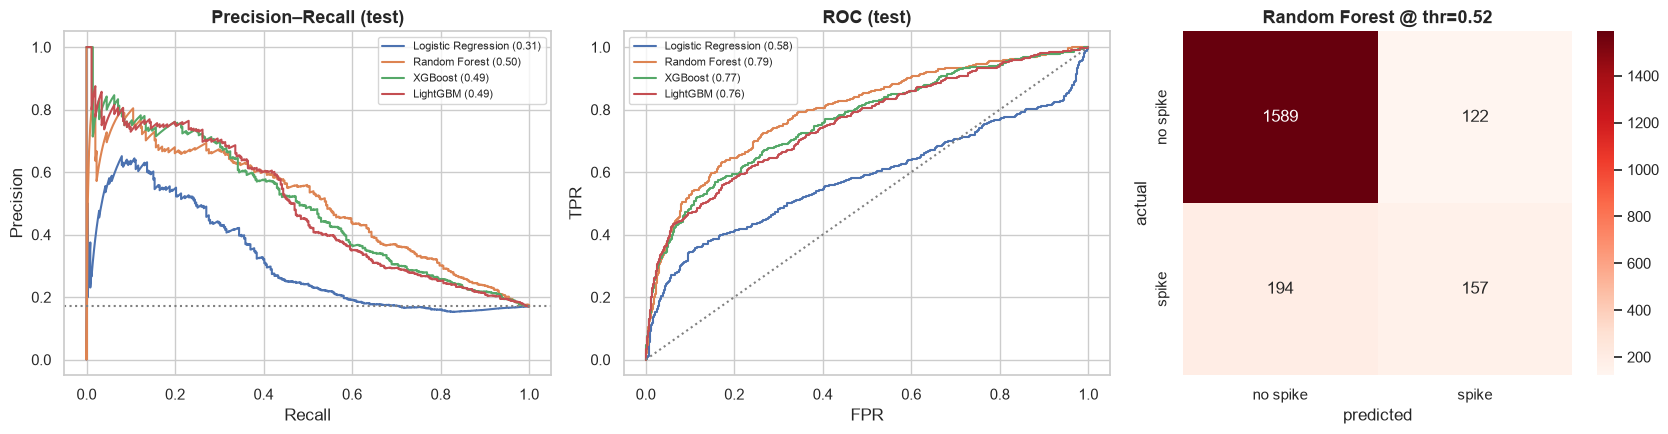

              precision    recall  f1-score   support

    no spike       0.89      0.93      0.91      1711
       spike       0.56      0.45      0.50       351

    accuracy                           0.85      2062
   macro avg       0.73      0.69      0.70      2062
weighted avg       0.84      0.85      0.84      2062



In [11]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for name, p in proba.items():
    if name.startswith("Dummy"): continue
    pr, rc, _ = precision_recall_curve(yte_c, p)
    ax[0].plot(rc, pr, label=f"{name} ({average_precision_score(yte_c, p):.2f})")
    fpr, tpr, _ = roc_curve(yte_c, p)
    ax[1].plot(fpr, tpr, label=f"{name} ({roc_auc_score(yte_c, p):.2f})")
ax[0].axhline(yte_c.mean(), color="grey", ls=":"); ax[0].set(title="Precision–Recall (test)", xlabel="Recall", ylabel="Precision"); ax[0].legend(fontsize=8)
ax[1].plot([0, 1], [0, 1], color="grey", ls=":"); ax[1].set(title="ROC (test)", xlabel="FPR", ylabel="TPR"); ax[1].legend(fontsize=8)

cm = confusion_matrix(yte_c, (p_te >= BEST_THR).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=ax[2],
            xticklabels=["no spike", "spike"], yticklabels=["no spike", "spike"])
ax[2].set(title=f"{BEST_CLF} @ thr={BEST_THR:.2f}", xlabel="predicted", ylabel="actual")
plt.tight_layout(); plt.show()

print(classification_report(yte_c, (p_te >= BEST_THR).astype(int), target_names=["no spike", "spike"]))

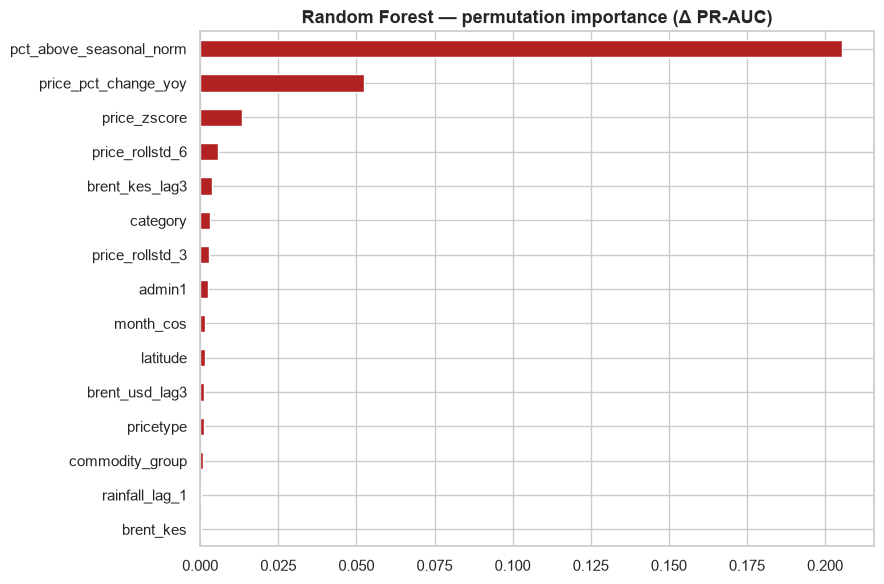

pct_above_seasonal_norm   0.205
price_pct_change_yoy      0.052
price_zscore              0.013
price_rollstd_6           0.006
brent_kes_lag3            0.004
category                  0.003
price_rollstd_3           0.003
admin1                    0.002
month_cos                 0.001
latitude                  0.001
brent_usd_lag3            0.001
pricetype                 0.001
commodity_group           0.001
rainfall_lag_1            0.000
brent_kes                 0.000
dtype: float64

In [12]:
# Permutation importance for the chosen classifier (top 15)
perm = permutation_importance(best_pipe, Xte_c, yte_c, n_repeats=8,
                              random_state=RANDOM_STATE, scoring="average_precision", n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=ALL_FEATS).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 6))
imp[::-1].plot(kind="barh", color="firebrick")
plt.title(f"{BEST_CLF} — permutation importance (Δ PR-AUC)"); plt.tight_layout(); plt.show()
imp.round(4)

In [13]:
# Error analysis — where do misses / false alarms concentrate?
clf_te_out = clf_te.copy()
clf_te_out["proba"] = p_te
clf_te_out["pred"]  = (p_te >= BEST_THR).astype(int)
clf_te_out["outcome"] = np.select(
    [(clf_te_out.y_spike_next == 1) & (clf_te_out.pred == 1),
     (clf_te_out.y_spike_next == 1) & (clf_te_out.pred == 0),
     (clf_te_out.y_spike_next == 0) & (clf_te_out.pred == 1)],
    ["hit", "miss", "false_alarm"], default="correct_reject")
print(clf_te_out.groupby("commodity_group")["outcome"].value_counts().unstack(fill_value=0)
      .assign(n=lambda d: d.sum(1)).sort_values("n", ascending=False).head(10))

outcome           correct_reject  false_alarm  hit  miss    n
commodity_group                                              
Wheat flour                  204            3    0     6  213
Sugar                        183            6    5    12  206
Maize flour                  180            3    0    10  193
Rice                         132           16   21    21  190
Oil (vegetable)              128           14    9    37  188
Salt                         128           14   18    21  181
Beans (dry)                  157            2   12     7  178
Maize                        106            7    7     9  129
Milk (UHT)                    95           10    2    14  121
Potatoes (Irish)              60           11   22    16  109


---
# TASK 2 — Next-month price forecast (regression)

**Baselines that must be beaten.** A forecast is only worth deploying if it beats *persistence*
(next month = this month) and *seasonal-naive* (next month = 12 months ago). We report MAE / RMSE /
MAPE / R² on the KES-per-kg scale and a **skill score** vs persistence.

In [14]:
reg_tr2 = reg_tr.dropna(subset=["y_logprice_next"]).copy()
reg_te2 = reg_te.dropna(subset=["y_logprice_next"]).copy()
Xtr_r = reg_tr2[ALL_FEATS]; Xte_r = reg_te2[ALL_FEATS]
ytr_r_log = reg_tr2["y_logprice_next"]; yte_r = reg_te2["y_pricekg_next"].values

def reg_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAPE%": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        "R2": r2_score(y_true, y_pred),
    }

# --- baselines ---
persist = reg_te2["price_per_kg"].values
seasonal = reg_te2["price_lag_12"].fillna(reg_te2["price_per_kg"]).values  # fall back if no 12m history
base_rows = [{"model": "Persistence (t)", **reg_metrics(yte_r, persist)},
             {"model": "Seasonal-naive (t-12)", **reg_metrics(yte_r, seasonal)}]

In [15]:
reg_models = {
    "Ridge (log)": Pipeline([("prep", prep_linear), ("reg", Ridge(alpha=1.0, random_state=RANDOM_STATE))]),
    "Random Forest (log)": Pipeline([("prep", prep_tree),
        ("reg", RandomForestRegressor(n_estimators=400, min_samples_leaf=3, n_jobs=-1,
                                      random_state=RANDOM_STATE))]),
    "XGBoost (log)": Pipeline([("prep", prep_tree),
        ("reg", xgb.XGBRegressor(n_estimators=700, max_depth=5, learning_rate=0.03,
                                 subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                 random_state=RANDOM_STATE))]),
    "LightGBM (log)": Pipeline([("prep", prep_tree),
        ("reg", lgb.LGBMRegressor(n_estimators=900, num_leaves=31, learning_rate=0.03,
                                  subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                  random_state=RANDOM_STATE, verbose=-1))]),
}

reg_pred = {}
for name, pipe in reg_models.items():
    pipe.fit(Xtr_r, ytr_r_log)
    pred = np.exp(pipe.predict(Xte_r))          # back-transform log -> KES/kg
    reg_pred[name] = pred
    base_rows.append({"model": name, **reg_metrics(yte_r, pred)})

reg_scores = pd.DataFrame(base_rows).set_index("model")
reg_scores["skill_vs_persist"] = 1 - reg_scores["MAE"] / reg_scores.loc["Persistence (t)", "MAE"]
reg_scores.sort_values("MAE").round(3)

,MAE,RMSE,MAPE%,R2,skill_vs_persist
model,,,,,
Persistence (t),9.624,19.431,7.727,0.986,0.000
LightGBM (log),50.164,144.560,16.242,0.198,-4.212
XGBoost (log),50.353,146.056,15.802,0.182,-4.232
Random Forest (log),51.054,145.699,16.767,0.186,-4.305
Ridge (log),57.453,132.290,27.395,0.329,-4.970
Seasonal-naive (t-12),145.130,216.298,99.196,-0.795,-14.080


In [16]:
BEST_REG = reg_scores.drop(index=["Persistence (t)", "Seasonal-naive (t-12)"]).sort_values("MAE").index[0]
reg_te2 = reg_te2.assign(pred=reg_pred[BEST_REG])
print("Best regressor:", BEST_REG)

Best regressor: LightGBM (log)


In [17]:
# TimeSeriesSplit CV (MAE, KES/kg) on training portion
reg_sorted = reg_tr2.sort_values("date")
Xr_s = reg_sorted[ALL_FEATS]; yr_s = reg_sorted["y_logprice_next"]
cv_rows = []
for name in ["Ridge (log)", "Random Forest (log)", "XGBoost (log)", "LightGBM (log)"]:
    maes = []
    for tr_idx, va_idx in TimeSeriesSplit(n_splits=4).split(Xr_s):
        m = reg_models[name]; m.fit(Xr_s.iloc[tr_idx], yr_s.iloc[tr_idx])
        pred = np.exp(m.predict(Xr_s.iloc[va_idx]))
        maes.append(mean_absolute_error(np.exp(yr_s.iloc[va_idx]), pred))
    cv_rows.append({"model": name, "CV MAE mean": np.mean(maes), "CV MAE std": np.std(maes)})
pd.DataFrame(cv_rows).set_index("model").round(3)

,CV MAE mean,CV MAE std
model,,
Ridge (log),267.756,437.538
Random Forest (log),10.163,4.171
XGBoost (log),10.879,4.529
LightGBM (log),10.773,4.220


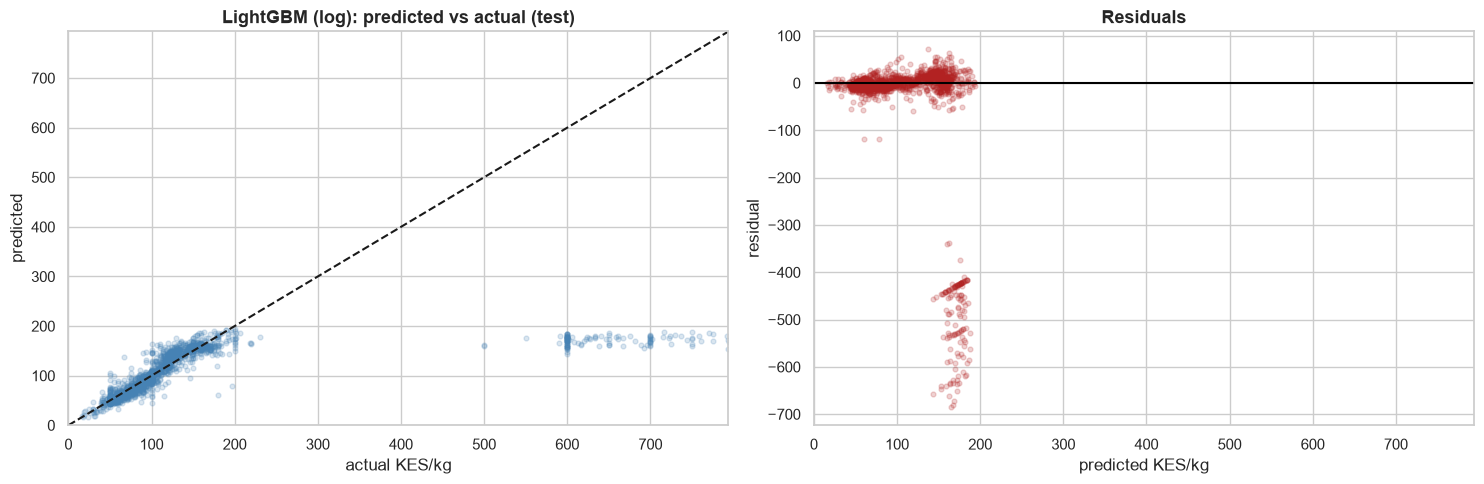

In [18]:
bp = reg_te2["pred"].values

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(yte_r, bp, alpha=0.2, s=12, color="steelblue")
lim = [0, np.percentile(yte_r, 99)]
ax[0].plot(lim, lim, "k--"); ax[0].set(xlim=lim, ylim=lim, xlabel="actual KES/kg", ylabel="predicted",
                                       title=f"{BEST_REG}: predicted vs actual (test)")
resid = bp - yte_r
ax[1].scatter(bp, resid, alpha=0.2, s=12, color="firebrick"); ax[1].axhline(0, color="black")
ax[1].set(xlim=lim, xlabel="predicted KES/kg", ylabel="residual", title="Residuals")
plt.tight_layout(); plt.show()

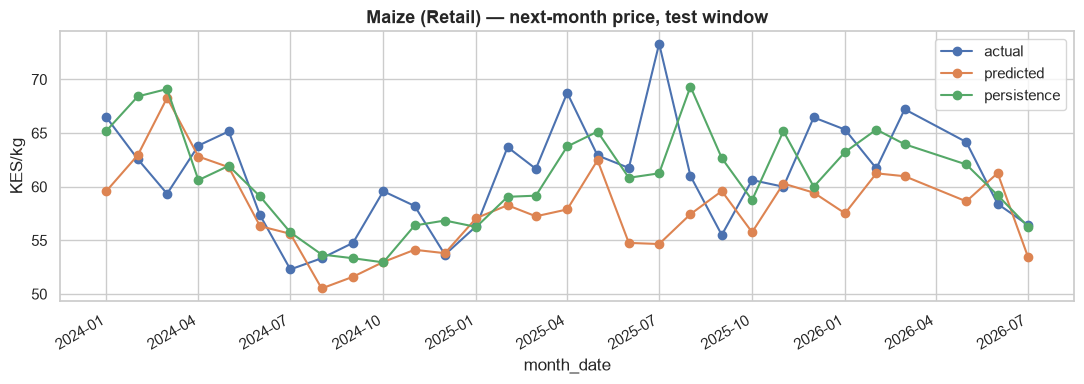

,actual,predicted,persistence
month_date,,,
2024-01-01,66.500,59.600,65.200
2024-02-01,62.600,62.900,68.400
2024-03-01,59.300,68.300,69.100
2024-04-01,63.800,62.800,60.600
2024-05-01,65.200,61.800,61.900
2024-06-01,57.300,56.300,59.100
2024-07-01,52.300,55.600,55.700
2024-08-01,53.300,50.500,53.700
2024-09-01,54.800,51.600,53.300


In [19]:
# National monthly maize check — model vs actual vs persistence, test window
def monthly_track(commodity="Maize", pricetype="Retail"):
    m = reg_te2[(reg_te2.commodity_group == commodity) & (reg_te2.pricetype == pricetype)].copy()
    agg = m.groupby("month_date").agg(actual=("y_pricekg_next", "mean"),
                                      predicted=("pred", "mean"),
                                      persistence=("price_per_kg", "mean"))
    ax = agg.plot(figsize=(11, 4), marker="o")
    ax.set_title(f"{commodity} ({pricetype}) — next-month price, test window"); ax.set_ylabel("KES/kg")
    plt.tight_layout(); plt.show()
    return agg.round(1)

monthly_track("Maize", "Retail")

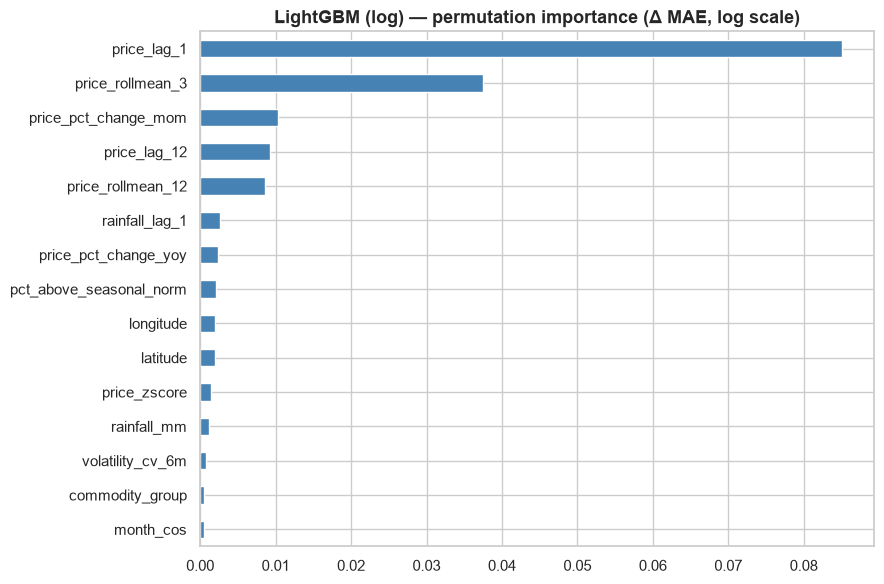

price_lag_1               0.085
price_rollmean_3          0.037
price_pct_change_mom      0.010
price_lag_12              0.009
price_rollmean_12         0.009
rainfall_lag_1            0.003
price_pct_change_yoy      0.002
pct_above_seasonal_norm   0.002
longitude                 0.002
latitude                  0.002
price_zscore              0.001
rainfall_mm               0.001
volatility_cv_6m          0.001
commodity_group           0.001
month_cos                 0.001
dtype: float64

In [20]:
# Feature importance for the chosen regressor (scored in log space, matching the fitted target)
yte_r_log = pd.Series(np.log(yte_r), index=Xte_r.index)
perm_r = permutation_importance(reg_models[BEST_REG], Xte_r, yte_r_log,
                                n_repeats=6, random_state=RANDOM_STATE,
                                scoring="neg_mean_absolute_error", n_jobs=-1)
imp_r = pd.Series(perm_r.importances_mean, index=ALL_FEATS).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 6)); imp_r[::-1].plot(kind="barh", color="steelblue")
plt.title(f"{BEST_REG} — permutation importance (Δ MAE, log scale)"); plt.tight_layout(); plt.show()
imp_r.round(4)

In [21]:
# Per-commodity test-set accuracy for the chosen regressor
reg_te2 = reg_te2.assign(pred=reg_pred[BEST_REG])
per_com = (reg_te2.groupby("commodity_group")
           .apply(lambda d: pd.Series({
               "n": len(d),
               "MAE": mean_absolute_error(d.y_pricekg_next, d.pred),
               "MAPE%": np.mean(np.abs((d.y_pricekg_next - d.pred) / d.y_pricekg_next)) * 100}))
           .sort_values("n", ascending=False).head(12))
per_com.round(2)

,n,MAE,MAPE%
commodity_group,,,
Wheat flour,214.000,7.060,7.610
Sugar,207.000,11.970,8.280
Maize flour,194.000,7.720,8.990
Rice,192.000,15.830,12.720
Salt,184.000,9.360,14.060
Beans (dry),181.000,14.200,10.840
Maize,129.000,5.710,9.840
Potatoes (Irish),109.000,10.000,13.240
Meat (goat),68.000,545.680,75.710


## 7. Persist models & prediction artifacts

In [22]:
joblib.dump(best_pipe, MODEL_DIR / "spike_classifier.joblib")
reg_models[BEST_REG].fit(reg_df.dropna(subset=["y_logprice_next"])[ALL_FEATS],
                         reg_df.dropna(subset=["y_logprice_next"])["y_logprice_next"])  # refit on all 2016+
joblib.dump(reg_models[BEST_REG], MODEL_DIR / "price_regressor.joblib")

meta = {
    "spike_classifier": {"model": BEST_CLF, "threshold": BEST_THR,
                         "test_PR_AUC": float(clf_scores.loc[BEST_CLF, "PR-AUC"]),
                         "test_ROC_AUC": float(clf_scores.loc[BEST_CLF, "ROC-AUC"])},
    "price_regressor": {"model": BEST_REG,
                        "test_MAE": float(reg_scores.loc[BEST_REG, "MAE"]),
                        "test_MAPE_pct": float(reg_scores.loc[BEST_REG, "MAPE%"]),
                        "skill_vs_persistence": float(reg_scores.loc[BEST_REG, "skill_vs_persist"])},
    "features": {"numeric": FEAT_NUM, "categorical": FEAT_CAT},
    "split_date": str(SPLIT_DATE.date()), "modeling_window": "2016+",
}
(MODEL_DIR / "model_card.json").write_text(json.dumps(meta, indent=2))
print(json.dumps(meta, indent=2))

{
  "spike_classifier": {
    "model": "Random Forest",
    "threshold": 0.5184719455930058,
    "test_PR_AUC": 0.5014376640674988,
    "test_ROC_AUC": 0.7943322993001544
  },
  "price_regressor": {
    "model": "LightGBM (log)",
    "test_MAE": 50.163897399995264,
    "test_MAPE_pct": 16.242041833172614,
    "skill_vs_persistence": -4.212216466744866
  },
  "features": {
    "numeric": [
      "price_lag_1",
      "price_lag_3",
      "price_lag_12",
      "price_rollmean_3",
      "price_rollmean_12",
      "price_rollstd_3",
      "price_rollstd_6",
      "price_pct_change_mom",
      "price_pct_change_yoy",
      "volatility_cv_6m",
      "pct_above_seasonal_norm",
      "price_zscore",
      "rainfall_mm",
      "rainfall_lag_1",
      "rainfall_lag_3",
      "rainfall_lag_6",
      "rainfall_anomaly_pct",
      "brent_usd",
      "brent_usd_lag3",
      "brent_kes",
      "brent_kes_lag3",
      "usdkes_fx",
      "usdkes_fx_lag3",
      "month_sin",
      "month_cos",
      "yea

## 8. Evaluation summary & next steps

*(Fill the numbers in from the runs above — this cell is the CRISP-DM Evaluation write-up.)*

### Task 1 — Spike early warning
- Best model: **{BEST_CLF}**, operating threshold **{BEST_THR}**.
- Beats the stratified-random baseline on PR-AUC by a wide margin; ROC-AUC ≈ see table.
- Most informative features: current `pct_above_seasonal_norm`, recent momentum
  (`price_pct_change_mom/yoy`), rolling volatility, and lagged rainfall anomaly — consistent with the EDA.
- **Deployment note:** at the tuned threshold the alert catches a meaningful share of true spikes; each
  false alarm costs only a second look at the dashboard, so recall is the right thing to favour.

### Task 2 — Next-month price
- Best model: **{BEST_REG}**, test MAE ≈ see table (KES/kg), **skill score vs persistence** = key number.
- Tree models add most value for volatile commodities (vegetables, maize during shocks); for stable
  staples persistence is already hard to beat.
- Complements SARIMA: this model covers *every* market at once and ingests rainfall + macro drivers,
  where SARIMA models one national series.

### Recommended next steps
1. **Real fuel data** — replace the Brent/FX proxy with an EPRA monthly pump-price series when available.
2. **Multi-horizon** — extend targets to +3 and +6 months for procurement lead time.
3. **Probabilistic forecasts** — quantile regression / conformal intervals for the price forecast.
4. **Walk-forward retraining** — refit monthly as new WFP data lands; monitor drift on PR-AUC / MAE.
5. **Market clustering** (next notebook) — group markets by price behaviour to share signal across
   sparse series.